# AI-Powered Fraud Detection — Machine Learning Classification

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df=pd.read_csv(r"C:\Users\mrhas\Downloads\Credit-Card-Transactions.csv")

In [3]:
df.head()

,transaction_id,customer_id,transaction_hour,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label
0,TXN0000000,CUST00102,13,395.0,0.0,online_services,CA,mobile,1,1,174.76,6.0,5.0,257.88,0
1,TXN0000001,CUST00435,23,NaN,0.0,grocery,US,mobile,0,0,428.85,1.0,1.0,495.38,0
2,TXN0000002,CUST00860,25,1212.0,0.0,grocery,US,mobile,0,0,411.69,0.0,2.0,-640.15,0
3,TXN0000003,CUST00270,21,126.0,0.0,electronics,US,tablet,0,0,128.27,3.0,2.0,546.43,0
4,TXN0000004,CUST00106,6,-705.0,2.0,restaurant,US,mobile,0,0,736.38,2.0,11.0,462.64,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5300 entries, 0 to 5299
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transaction_id              5300 non-null   str    
 1   customer_id                 5300 non-null   str    
 2   transaction_hour            5300 non-null   int64  
 3   account_age_days            5280 non-null   float64
 4   previous_chargebacks        5285 non-null   float64
 5   merchant_category           5282 non-null   str    
 6   transaction_country         5278 non-null   str    
 7   device_type                 5280 non-null   str    
 8   is_international            5300 non-null   int64  
 9   is_high_risk_merchant       5300 non-null   int64  
 10  transaction_amount          5278 non-null   float64
 11  transaction_velocity_1h     5290 non-null   float64
 12  transaction_velocity_24h    5282 non-null   float64
 13  avg_transaction_amount_30d  5278 non-null   

In [5]:
df.duplicated().sum()

np.int64(300)

In [6]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
transaction_hour               0
account_age_days              20
previous_chargebacks          15
merchant_category             18
transaction_country           22
device_type                   20
is_international               0
is_high_risk_merchant          0
transaction_amount            22
transaction_velocity_1h       10
transaction_velocity_24h      18
avg_transaction_amount_30d    22
risk_label                     0
dtype: int64

In [8]:
df.describe()

,transaction_hour,account_age_days,previous_chargebacks,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label
count,5300.000000,5280.000000,5285.000000,5300.000000,5300.000000,5278.000000,5290.000000,5282.000000,5278.000000,5300.000000
mean,11.767358,597.459280,0.229707,0.409811,0.303019,462.036129,1.044423,3.768080,463.479504,0.099434
std,6.946431,435.123791,0.628484,0.491845,0.459607,554.276432,1.254416,3.120168,262.455610,0.299272
min,-23.000000,-1024.000000,0.000000,0.000000,0.000000,-810.420000,0.000000,0.000000,-771.760000,0.000000
25%,6.000000,280.000000,0.000000,0.000000,0.000000,162.592500,0.000000,1.000000,296.855000,0.000000
50%,12.000000,502.000000,0.000000,0.000000,0.000000,286.980000,1.000000,3.000000,407.645000,0.000000
75%,18.000000,805.250000,0.000000,1.000000,1.000000,537.287500,2.000000,6.000000,567.265000,0.000000
max,30.000000,3529.000000,4.000000,1.000000,1.000000,7000.000000,9.000000,17.000000,3111.490000,1.000000


In [9]:
df['risk_label'].value_counts()

risk_label
0    4773
1     527
Name: count, dtype: int64

## Data Cleaning

In [12]:
df.shape

(5300, 15)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(5000, 15)

In [17]:
df[df["transaction_hour"] < 0]

,transaction_id,customer_id,transaction_hour,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label
12,TXN0000012,CUST00330,-20,426.0,0.0,online_services,US,mobile,0,1,229.24,0.0,1.0,472.24,0
504,TXN0000504,CUST00625,-23,1011.0,0.0,travel,CA,mobile,1,1,1072.86,3.0,7.0,808.00,0
4998,TXN0004998,CUST00903,-1,NaN,0.0,online_services,US,mobile,0,1,337.90,3.0,6.0,516.31,0


In [18]:
numeric_cols = [
    "transaction_hour",
    ""
    "account_age_days",
    "previous_chargebacks",
    "transaction_amount",
    "transaction_velocity_1h",
    "transaction_velocity_24h",
    "avg_transaction_amount_30d"
]

for col in numeric_cols:
    print(f"\n{col}")
    print("Negative values:", (df[col] < 0).sum())


transaction_hour
Negative values: 3

account_age_days
Negative values: 10

previous_chargebacks
Negative values: 0

transaction_amount
Negative values: 9

transaction_velocity_1h
Negative values: 0

transaction_velocity_24h
Negative values: 0

avg_transaction_amount_30d
Negative values: 7


In [19]:
df.loc[df["transaction_hour"] < 0, "transaction_hour"] = np.nan

df.loc[df["account_age_days"] < 0, "account_age_days"] = np.nan

df.loc[df["transaction_amount"] < 0, "transaction_amount"] = np.nan

df.loc[df["avg_transaction_amount_30d"] < 0, "avg_transaction_amount_30d"] = np.nan

In [21]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
transaction_hour               3
account_age_days              28
previous_chargebacks          15
merchant_category             18
transaction_country           21
device_type                   19
is_international               0
is_high_risk_merchant          0
transaction_amount            29
transaction_velocity_1h       10
transaction_velocity_24h      15
avg_transaction_amount_30d    29
risk_label                     0
dtype: int64

In [22]:
df = df.drop(
    ["transaction_id", "customer_id"],
    axis=1
)

In [23]:
df

,transaction_hour,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label
0,13.0,395.0,0.0,online_services,CA,mobile,1,1,174.76,6.0,5.0,257.88,0
1,23.0,NaN,0.0,grocery,US,mobile,0,0,428.85,1.0,1.0,495.38,0
2,25.0,1212.0,0.0,grocery,US,mobile,0,0,411.69,0.0,2.0,NaN,0
3,21.0,126.0,0.0,electronics,US,tablet,0,0,128.27,3.0,2.0,546.43,0
4,6.0,NaN,2.0,restaurant,US,mobile,0,0,736.38,2.0,11.0,462.64,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,8.0,226.0,0.0,restaurant,US,desktop,0,0,402.24,1.0,3.0,277.32,0
4996,14.0,1086.0,0.0,electronics,US,mobile,0,0,147.99,1.0,4.0,123.45,0
4997,19.0,364.0,0.0,restaurant,US,mobile,0,0,184.36,0.0,2.0,239.31,0
4998,NaN,NaN,0.0,online_services,US,mobile,0,1,337.90,3.0,6.0,516.31,0


In [52]:
num=df.select_dtypes(include=['int64','float64']).columns.tolist()
num.remove('risk_label')
num.remove('is_international')
num.remove('is_high_risk_merchant')

In [53]:
num

['transaction_hour',
 'account_age_days',
 'previous_chargebacks',
 'transaction_amount',
 'transaction_velocity_1h',
 'transaction_velocity_24h',
 'avg_transaction_amount_30d',
 'amount_ratio']

In [32]:
cat=df.select_dtypes(include=['object']).columns.tolist()

C:\Users\mrhas\AppData\Local\Temp\ipykernel_2748\1036630735.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=df.select_dtypes(include=['object']).columns.tolist()


In [33]:
cat

['merchant_category', 'transaction_country', 'device_type']

In [40]:
binary = [
    col for col in df.columns
    if df[col].nunique() == 2
]
binary.remove('risk_label')
print(binary)

['is_international', 'is_high_risk_merchant']


<Axes: xlabel='is_international', ylabel='count'>

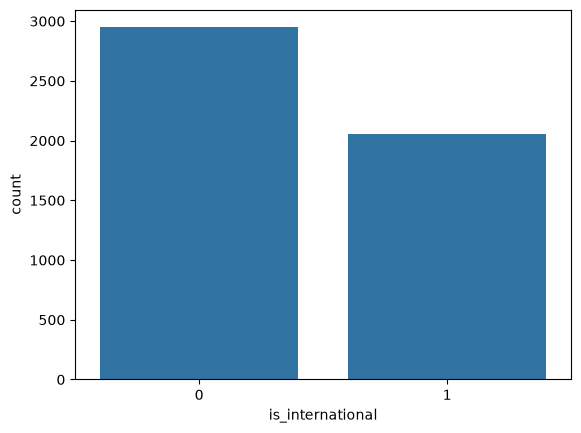

In [39]:
sns.countplot(x='is_international',data=df)

# Feature Engineering

In [41]:
df["amount_ratio"] = (
    df["transaction_amount"] /
    df["avg_transaction_amount_30d"]
)

In [42]:
df

,transaction_hour,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label,amount_ratio
0,13.0,395.0,0.0,online_services,CA,mobile,1,1,174.76,6.0,5.0,257.88,0,0.677680
1,23.0,NaN,0.0,grocery,US,mobile,0,0,428.85,1.0,1.0,495.38,0,0.865699
2,25.0,1212.0,0.0,grocery,US,mobile,0,0,411.69,0.0,2.0,NaN,0,NaN
3,21.0,126.0,0.0,electronics,US,tablet,0,0,128.27,3.0,2.0,546.43,0,0.234742
4,6.0,NaN,2.0,restaurant,US,mobile,0,0,736.38,2.0,11.0,462.64,0,1.591691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,8.0,226.0,0.0,restaurant,US,desktop,0,0,402.24,1.0,3.0,277.32,0,1.450454
4996,14.0,1086.0,0.0,electronics,US,mobile,0,0,147.99,1.0,4.0,123.45,0,1.198785
4997,19.0,364.0,0.0,restaurant,US,mobile,0,0,184.36,0.0,2.0,239.31,0,0.770382
4998,NaN,NaN,0.0,online_services,US,mobile,0,1,337.90,3.0,6.0,516.31,0,0.654452


In [46]:
from sklearn.model_selection import train_test_split

X = df.drop("risk_label", axis=1)
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 13)
X_test: (1000, 13)
y_train: (4000,)
y_test: (1000,)


In [54]:
print("Numerical:", num)
print("Categorical:", cat)
print("Binary:", binary)

Numerical: ['transaction_hour', 'account_age_days', 'previous_chargebacks', 'transaction_amount', 'transaction_velocity_1h', 'transaction_velocity_24h', 'avg_transaction_amount_30d', 'amount_ratio']
Categorical: ['merchant_category', 'transaction_country', 'device_type']
Binary: ['is_international', 'is_high_risk_merchant']


In [55]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("nume", numeric_pipeline, num),
    ("cato", categorical_pipeline, cat),
    ("bin", "passthrough", binary)
])

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    accuracy = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="accuracy"
    )

    macrof1 = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="f1_macro"
    )

    print(
        f"{name} -> "
        f"Accuracy: {accuracy.mean():.3f}, "
        f"F1: {macrof1.mean():.3f}"
    )

Logistic Regression -> Accuracy: 0.884, F1: 0.774
Decision Tree -> Accuracy: 0.935, F1: 0.808
Random Forest -> Accuracy: 0.947, F1: 0.861
Gradient Boosting -> Accuracy: 0.956, F1: 0.873


In [57]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

In [58]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['transaction_hour','account_age_days','previous_chargebacks',..., 'transaction_velocity_24h','avg_transaction_amount_30d','amount_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nume', ...), ('cato', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are d

In [59]:
y_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.958
Precision: 0.8152173913043478
Recall: 0.75
F1 Score: 0.78125

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       900
           1       0.82      0.75      0.78       100

    accuracy                           0.96      1000
   macro avg       0.89      0.87      0.88      1000
weighted avg       0.96      0.96      0.96      1000


Confusion Matrix:
[[883  17]
 [ 25  75]]


In [62]:
y_pred = final_model.predict(X_test)

In [63]:
import joblib

joblib.dump(final_model, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!
